# Revisión visual de las ventanas tempranas

Abre el parquet generado por `generate_early_windows.py` (OpenUniverse + KN inyectadas) y dibuja una grilla de **objetos al azar** para chequear que las curvas estén bien. Re-ejecuta la celda del plot para sacar otra muestra aleatoria. Paleta y nombres de banda (`R Z Y J H F`) como en `hourglass_eda.ipynb`.

El eje X es **days_since_detection** (días desde la 1ª detección S/N≥5), la convención unificada del pipeline. Cambia `PARQUET_PATH` a `early_windows_wide.parquet` para el tier WIDE.

La última sección carga además el **HDF5 de kilonovas** generado en `kilonova_dataloader.ipynb` y lo dibuja con las mismas funciones.

In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parquet generado por generate_early_windows.py. Override con EARLY_WINDOWS_PARQUET; por defecto,
# ruta relativa al notebook (early_windows_deep.parquet). Usa early_windows_wide.parquet para WIDE.
PARQUET_PATH = Path(os.environ.get(
    "EARLY_WINDOWS_PARQUET", Path.cwd() / "early_windows_deep.parquet",
)).resolve()

# Mismos nombres y paleta que hourglass_eda.ipynb.
BAND_ORDER = ["R", "Z", "Y", "J", "H", "F"]
BAND_COLORS = {band: plt.cm.turbo(position)
               for band, position in zip(BAND_ORDER, np.linspace(0.05, 0.95, len(BAND_ORDER)))}
BASE_CADENCE_DAYS = 5.0

windows = pd.read_parquet(PARQUET_PATH)
# Nombre corto de banda (inicial del nombre galsim: R062 -> R), como en hourglass_eda.
windows["band_letter"] = windows["band"].str[0]
BANDS_PRESENT = [band for band in BAND_ORDER if band in set(windows["band_letter"])]
TIER = "DEEP" if "F" in BANDS_PRESENT else "WIDE"

print(f"{windows['object_id'].nunique()} objetos, {len(windows)} filas, "
      f"tier {TIER}: {'/'.join(BANDS_PRESENT)}")
windows.head()

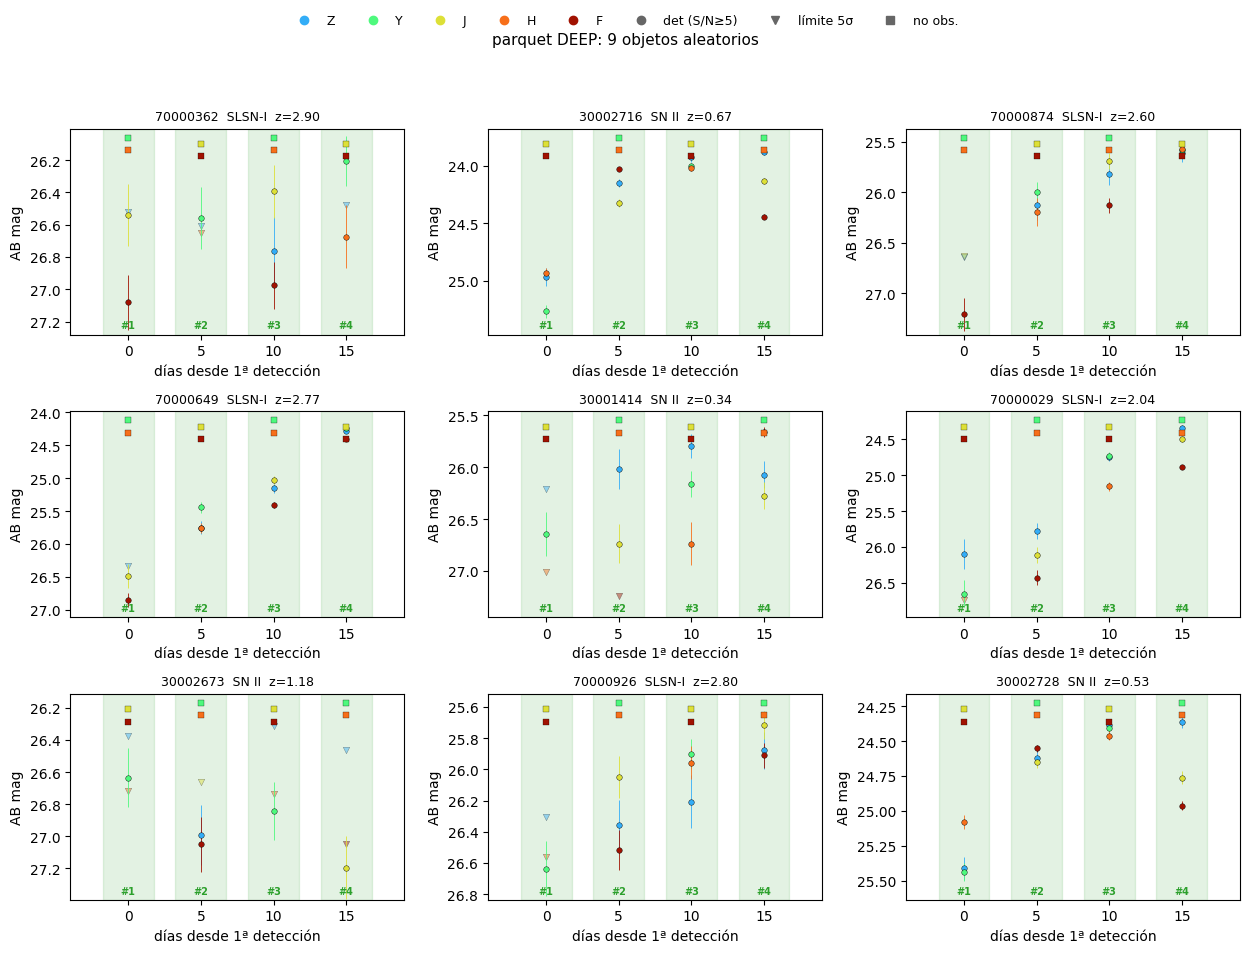

In [2]:
def plot_window(window, ax, bands_present):
    """Las épocas de un objeto en un eje. ○ detección (con barra de error), ▽ límite 5σ,
    □ banda no observada en esa visita (cadencia, solo si el df trae filas observed=False),
    épocas sombreadas/numeradas (verde = con detección). Eje X = días desde la 1ª detección.
    Las bandas se identifican por color en la leyenda de la figura (arriba)."""
    bands_here = [band for band in bands_present if (window["band_letter"] == band).any()]
    epoch_transform = ax.get_xaxis_transform()
    for index, band in enumerate(bands_here):
        band_rows = window[window["band_letter"] == band]
        color = BAND_COLORS[band]
        observed_rows = band_rows[band_rows["observed"]]
        detections = observed_rows[observed_rows["detected"]]
        upper_limits = observed_rows[~observed_rows["detected"]]
        not_observed = band_rows.loc[~band_rows["observed"], "days_since_detection"].to_numpy()
        if len(detections) > 0:
            ax.errorbar(detections["days_since_detection"], detections["mag_observed"], yerr=detections["mag_err"],
                        fmt="o", ms=4, color=color, ecolor=color, elinewidth=0.6,
                        capsize=0, mec="k", mew=0.3)
        if len(upper_limits) > 0:
            ax.scatter(upper_limits["days_since_detection"], upper_limits["mag_limit_5sigma"], marker="v",
                       s=22, color=color, edgecolor="k", linewidth=0.3, alpha=0.45)
        if len(not_observed) > 0:
            y_rug = 0.985 - 0.03 * index
            ax.scatter(not_observed, np.full(len(not_observed), y_rug), marker="s", s=14,
                       color=color, edgecolor="k", linewidth=0.2, transform=epoch_transform, zorder=5)

    epoch_times = np.sort(window["days_since_detection"].unique())
    pad = BASE_CADENCE_DAYS * 0.8
    ax.set_xlim(epoch_times.min() - pad, epoch_times.max() + pad)
    observed = window[window["observed"]]
    shown_mag = pd.concat([observed.loc[observed["detected"], "mag_observed"],
                           observed.loc[~observed["detected"], "mag_limit_5sigma"]]).dropna()
    if len(shown_mag):
        margin = max(0.2, 0.1 * (shown_mag.max() - shown_mag.min()))
        ax.set_ylim(shown_mag.max() + margin, shown_mag.min() - margin)  # eje invertido
    for order, epoch_time in enumerate(epoch_times, start=1):
        has_detection = bool(window[(window["days_since_detection"] == epoch_time) & window["detected"]].shape[0])
        ax.axvspan(epoch_time - BASE_CADENCE_DAYS * 0.35, epoch_time + BASE_CADENCE_DAYS * 0.35,
                   color="tab:green" if has_detection else "0.5", alpha=0.13, zorder=0)
        ax.text(epoch_time, 0.02, f"#{order}", transform=ax.get_xaxis_transform(),
                ha="center", va="bottom", fontsize=7, fontweight="bold",
                color="tab:green" if has_detection else "0.4")

    info = window.iloc[0]
    ax.set_title(f"{info['object_id']}  {info['label']}  z={info['z_CMB']:.2f}", fontsize=9)
    ax.set_xlabel("días desde 1ª detección")
    ax.set_ylabel("AB mag")


def plot_random_windows(windows, bands_present, sample_label, number=9, ncols=3, rng=None):
    """Dibuja `number` objetos al azar de `windows` en una grilla. Re-ejecutar -> nueva muestra.
    Sirve para el parquet (early_windows_{tier}) y para el HDF5 de kilonovas (mismo esquema largo).
    Las bandas (R Z Y J H F) van como leyenda de color arriba; cada panel titula object_id, tipo y z."""
    rng = rng if rng is not None else np.random.default_rng()
    objects = windows["object_id"].unique()
    chosen = rng.choice(objects, size=min(number, len(objects)), replace=False)
    nrows = int(np.ceil(len(chosen) / ncols))
    figure, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows), squeeze=False)
    for index, object_id in enumerate(chosen):
        ax = axes[index // ncols][index % ncols]
        plot_window(windows[windows["object_id"] == object_id].sort_values(["days_since_detection", "band"]),
                    ax, bands_present)
    for index in range(len(chosen), nrows * ncols):
        axes[index // ncols][index % ncols].axis("off")

    band_handles = [plt.Line2D([], [], marker="o", ls="", color=BAND_COLORS[band], label=band)
                    for band in bands_present]
    symbol_handles = [plt.Line2D([], [], marker="o", ls="", color="0.4", label="det (S/N≥5)"),
                      plt.Line2D([], [], marker="v", ls="", color="0.4", label="límite 5σ"),
                      plt.Line2D([], [], marker="s", ls="", color="0.4", label="no obs.")]
    figure.legend(handles=band_handles + symbol_handles, loc="upper center",
                  ncol=len(band_handles) + len(symbol_handles), frameon=False, fontsize=9,
                  bbox_to_anchor=(0.5, 0.995))
    figure.suptitle(f"{sample_label}: {len(chosen)} objetos aleatorios", fontsize=11, y=0.965)
    figure.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


plot_random_windows(windows, BANDS_PRESENT, f"parquet {TIER}", number=9, ncols=3)

## Kilonovas del HDF5 (`kilonova_dataloader.ipynb` → `generate_kilonova_hdf5`)

Carga el HDF5 de kilonovas (un grupo por objeto) generado en `kilonova_dataloader.ipynb` y dibuja una muestra al azar con las **mismas** funciones que el parquet. La ventana KN solo trae filas observadas (anchor + 2 por visita), así que no aparecen cuadrados de "no observada"; el eje X es days_since_detection igual que el parquet.

Cambia `KN_HDF5_PATH` al archivo que hayas generado.

In [ ]:
import os
from pathlib import Path

import h5py

# HDF5 de kilonovas generado por generate_kilonova_hdf5 en kilonova_dataloader.ipynb. Override con
# KN_HDF5_PATH; por defecto kilonova_windows_deep.hdf5 junto al notebook (usa _wide.hdf5 para WIDE).
KN_HDF5_PATH = Path(os.environ.get(
    "KN_HDF5_PATH", Path.cwd() / "kilonova_windows_deep.hdf5",
)).resolve()


def load_kilonova_hdf5(path):
    """HDF5 de kilonovas (un grupo por objeto) -> DataFrame largo con las mismas columnas que el parquet,
    para reusar plot_window/plot_random_windows. La ventana KN solo guarda filas observadas (anchor + 2
    por visita), así que observed=True para todas (sin cuadrados de no-observada)."""
    rows = []
    with h5py.File(path, "r") as hdf5:
        file_bands = hdf5.attrs.get("bands", "")
        for object_id in hdf5.keys():
            group = hdf5[object_id]
            frame = pd.DataFrame({
                "object_id": object_id,
                "label": group.attrs["label"],
                "z_CMB": float(group.attrs["redshift"]),
                "days_since_detection": group["days_since_detection"][:],
                "band": [band.decode() for band in group["band"][:]],
                "mag_observed": group["mag_observed"][:],
                "mag_err": group["mag_err"][:],
                "mag_limit_5sigma": group["mag_limit_5sigma"][:],
                "detected": group["detected"][:],
            })
            frame["observed"] = True
            rows.append(frame)
    kilonovas = pd.concat(rows, ignore_index=True)
    kilonovas["band_letter"] = kilonovas["band"].str[0]
    return kilonovas, file_bands


kn_windows, kn_file_bands = load_kilonova_hdf5(KN_HDF5_PATH)
KN_BANDS_PRESENT = [band for band in BAND_ORDER if band in set(kn_windows["band_letter"])]
print(f"{kn_windows['object_id'].nunique()} kilonovas, {len(kn_windows)} filas, "
      f"bandas {'/'.join(KN_BANDS_PRESENT)}  (tier del archivo: {kn_file_bands})")
plot_random_windows(kn_windows, KN_BANDS_PRESENT, "kilonovas HDF5", number=9, ncols=3)